# **Predicting Diabetes with Machine Learning: An Applied Classification Approach**

**Problem Statement**

One of the most common chronic illnesses in the world is diabetes, and preventing long-term problems requires early detection. The dataset utilized in this study provides health, demographic, and lifestyle information on individuals and labels whether each person is diabetic (Outcome = 1) or not (Outcome = 0).

The goal of this assignment is to develop machine learning models that can accurately predict diabetes based on given features. This project follows an applied ML approach as required by the course, including exploratory data analysis (EDA), training and tuning of at least two classification algorithms, performance comparison, and final recommendations.

Dataset: https://www.kaggle.com/datasets/marshalpatel3558/diabetes-prediction-dataset

# **Importing, Inspecting and Cleaning Dataset**

1. **Basic Imports**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. **Loading and Inspecting the Dataset**

In [7]:
df = pd.read_csv('/content/diabetes_dataset.csv', index_col=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            10000 non-null  int64  
 1   Sex                            10000 non-null  object 
 2   Ethnicity                      10000 non-null  object 
 3   BMI                            10000 non-null  float64
 4   Waist_Circumference            10000 non-null  float64
 5   Fasting_Blood_Glucose          10000 non-null  float64
 6   HbA1c                          10000 non-null  float64
 7   Blood_Pressure_Systolic        10000 non-null  int64  
 8   Blood_Pressure_Diastolic       10000 non-null  int64  
 9   Cholesterol_Total              10000 non-null  float64
 10  Cholesterol_HDL                10000 non-null  float64
 11  Cholesterol_LDL                10000 non-null  float64
 12  GGT                            10000 non-null  float

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,10000.0,NaN,NaN,NaN,44.6204,14.343489,20.0,32.0,45.0,57.0,69.0
Sex,10000,2,Female,5005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ethnicity,10000,4,Black,2539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,10000.0,NaN,NaN,NaN,29.41815,6.170866,18.5,24.1,29.5,34.7,40.0
Waist_Circumference,10000.0,NaN,NaN,NaN,94.79707,14.38329,70.0,82.2,94.9,107.0,120.0
Fasting_Blood_Glucose,10000.0,NaN,NaN,NaN,134.77621,37.633544,70.0,102.175,134.5,167.8,200.0
HbA1c,10000.0,NaN,NaN,NaN,9.50751,3.176421,4.0,6.8,9.5,12.3,15.0
Blood_Pressure_Systolic,10000.0,NaN,NaN,NaN,134.1637,26.110317,90.0,112.0,134.0,157.0,179.0
Blood_Pressure_Diastolic,10000.0,NaN,NaN,NaN,89.5587,17.237792,60.0,75.0,89.0,105.0,119.0
Cholesterol_Total,10000.0,NaN,NaN,NaN,225.16554,42.963744,150.0,187.875,225.5,262.4,300.0


In [9]:
df.shape

(10000, 20)

In [10]:
#Cleaning the Dataset
df.isna().sum()

,0
Age,0
Sex,0
Ethnicity,0
BMI,0
Waist_Circumference,0
Fasting_Blood_Glucose,0
HbA1c,0
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0
Cholesterol_Total,0


3. **Checking for Null Values**

In [11]:
df['Alcohol_Consumption'] = df['Alcohol_Consumption'].fillna(df['Alcohol_Consumption'].mode()[0])
df.isna().sum()

,0
Age,0
Sex,0
Ethnicity,0
BMI,0
Waist_Circumference,0
Fasting_Blood_Glucose,0
HbA1c,0
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0
Cholesterol_Total,0


4. **Create 3 class target based on HbA1c thresholds**

In [12]:
bins = [-np.inf, 5.7, 6.4, np.inf]
labels = ["Normal", "Prediabetes", "Diabetes"]
df["HbA1c_Category"] = pd.cut(df["HbA1c"], bins=bins, labels=labels, include_lowest=True)

print(df["HbA1c_Category"].value_counts())


HbA1c_Category
Diabetes       7784
Normal         1574
Prediabetes     642
Name: count, dtype: int64


# **Exploratory Data Analysis**

1. **EDA Hypotheses**

   A. Higher glucose levels increase diabetes likelihood.

   B. Older individuals are more likely to be diabetic.

   C. Higher BMI increases diabetes risk.

   D. Individuals with higher blood pressure tend to show more diabetes cases.

   E. Certain lifestyle factors (smoking, alcohol, activity, if included) are correlated with diabetes.

   F. Diabetes is likely imbalanced (Outcome = 1 is fewer than Outcome = 0).





1. **EDA Plots**

   A. Analyzing the distribution of target by means of a boxplot.



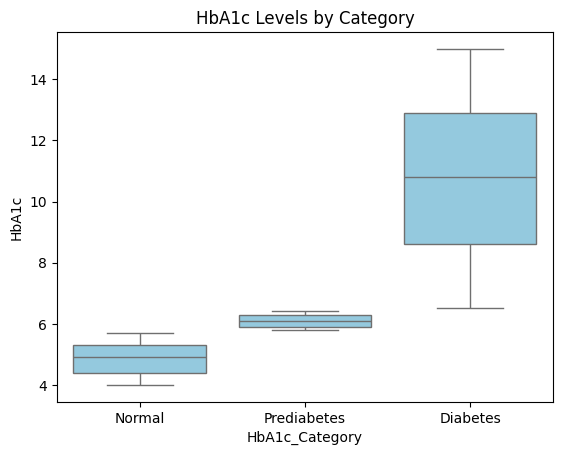

In [13]:
sns.boxplot(data=df, x="HbA1c_Category", y="HbA1c", color="skyblue")
plt.title("HbA1c Levels by Category")
plt.show()


**Interpretation:**

The boxplot clearly shows a clean separation between the three categories:

Normal -> lowest HbA1c

Prediabetes -> middle range

Diabetes -> highest, widest spread

B. Analyzing distribution of features by means of boxplot

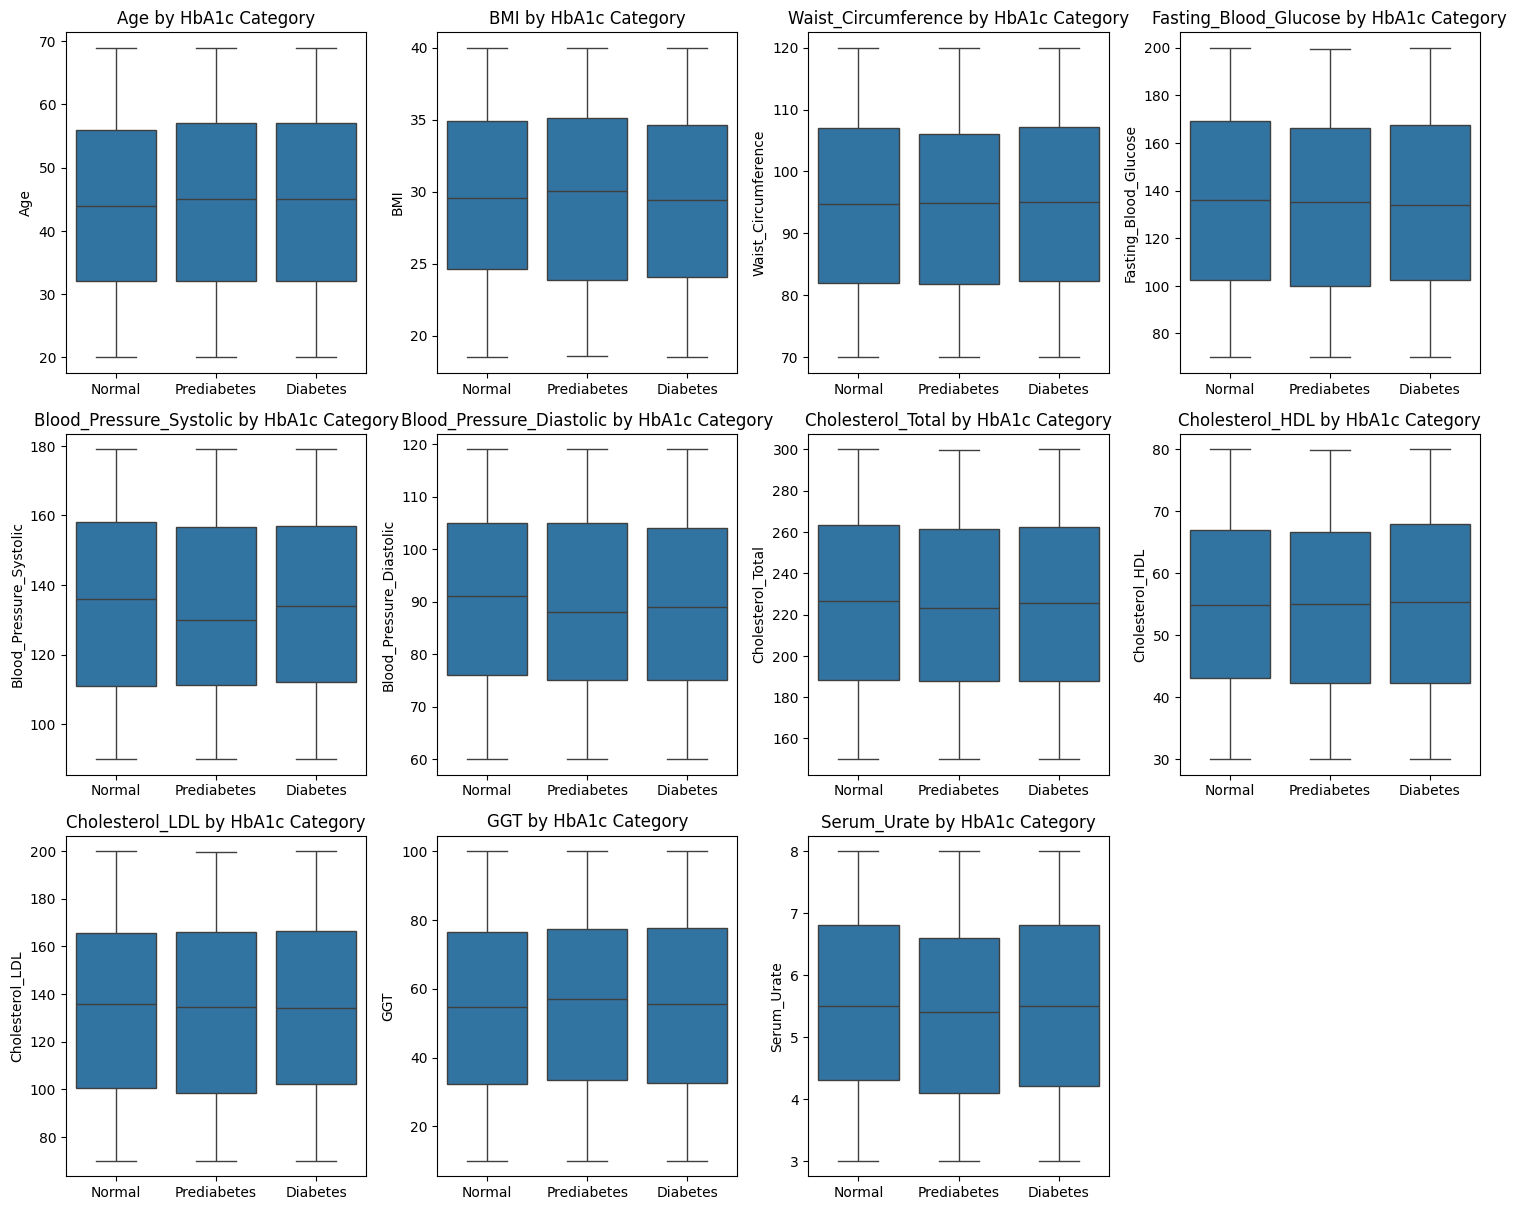

In [14]:
numeric_cols = ["Age", "BMI", "Waist_Circumference", "Fasting_Blood_Glucose",
                "Blood_Pressure_Systolic", "Blood_Pressure_Diastolic",
                "Cholesterol_Total", "Cholesterol_HDL", "Cholesterol_LDL",
                "GGT", "Serum_Urate"]

plt.figure(figsize=(15, 20))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(data=df, x="HbA1c_Category", y=col,
                order=["Normal", "Prediabetes", "Diabetes"])
    plt.title(f"{col} by HbA1c Category")
    plt.xlabel("")
    plt.tight_layout()

plt.show()

**Interpretation:**

The boxplots show distinct physiological variations among HbA1c groups.
 Glycemic deterioration is strongly correlated with fasting glucose, BMI, waist circumference, and age, all of which exhibit substantial increasing trends from normal to prediabetes to diabetes.  Liver (GGT) and uric acid levels reveal slight increases, whereas blood pressure and cholesterol show considerable increases.  These trends support the idea that metabolic risk factors deteriorate as the HbA1c category rises.

# **Correlation Analysis**

1. Correlation Heatmap

In [15]:
numeric_df = df[numeric_cols]

corr = numeric_df.corr()
corr

,Age,BMI,Waist_Circumference,Fasting_Blood_Glucose,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate
Age,1.000000,0.009352,-0.002602,0.002696,0.002470,0.011472,-0.005088,-0.005920,0.013345,-0.001156,-0.014950
BMI,0.009352,1.000000,-0.014291,-0.014478,-0.002235,-0.007163,0.004686,0.011594,0.000313,0.001105,0.002376
Waist_Circumference,-0.002602,-0.014291,1.000000,0.009080,-0.003090,-0.020355,0.005030,0.001525,-0.015512,0.009369,-0.003502
Fasting_Blood_Glucose,0.002696,-0.014478,0.009080,1.000000,-0.000139,0.004556,-0.015649,-0.002111,0.007528,-0.005200,-0.006336
Blood_Pressure_Systolic,0.002470,-0.002235,-0.003090,-0.000139,1.000000,0.000973,-0.003366,0.010689,0.007112,0.001255,-0.009286
Blood_Pressure_Diastolic,0.011472,-0.007163,-0.020355,0.004556,0.000973,1.000000,0.003907,-0.004867,-0.021146,0.001859,0.004302
Cholesterol_Total,-0.005088,0.004686,0.005030,-0.015649,-0.003366,0.003907,1.000000,-0.009679,-0.002241,0.013314,-0.004182
Cholesterol_HDL,-0.005920,0.011594,0.001525,-0.002111,0.010689,-0.004867,-0.009679,1.000000,0.005851,-0.009205,-0.008040
Cholesterol_LDL,0.013345,0.000313,-0.015512,0.007528,0.007112,-0.021146,-0.002241,0.005851,1.000000,-0.005989,0.023886
GGT,-0.001156,0.001105,0.009369,-0.005200,0.001255,0.001859,0.013314,-0.009205,-0.005989,1.000000,-0.002186


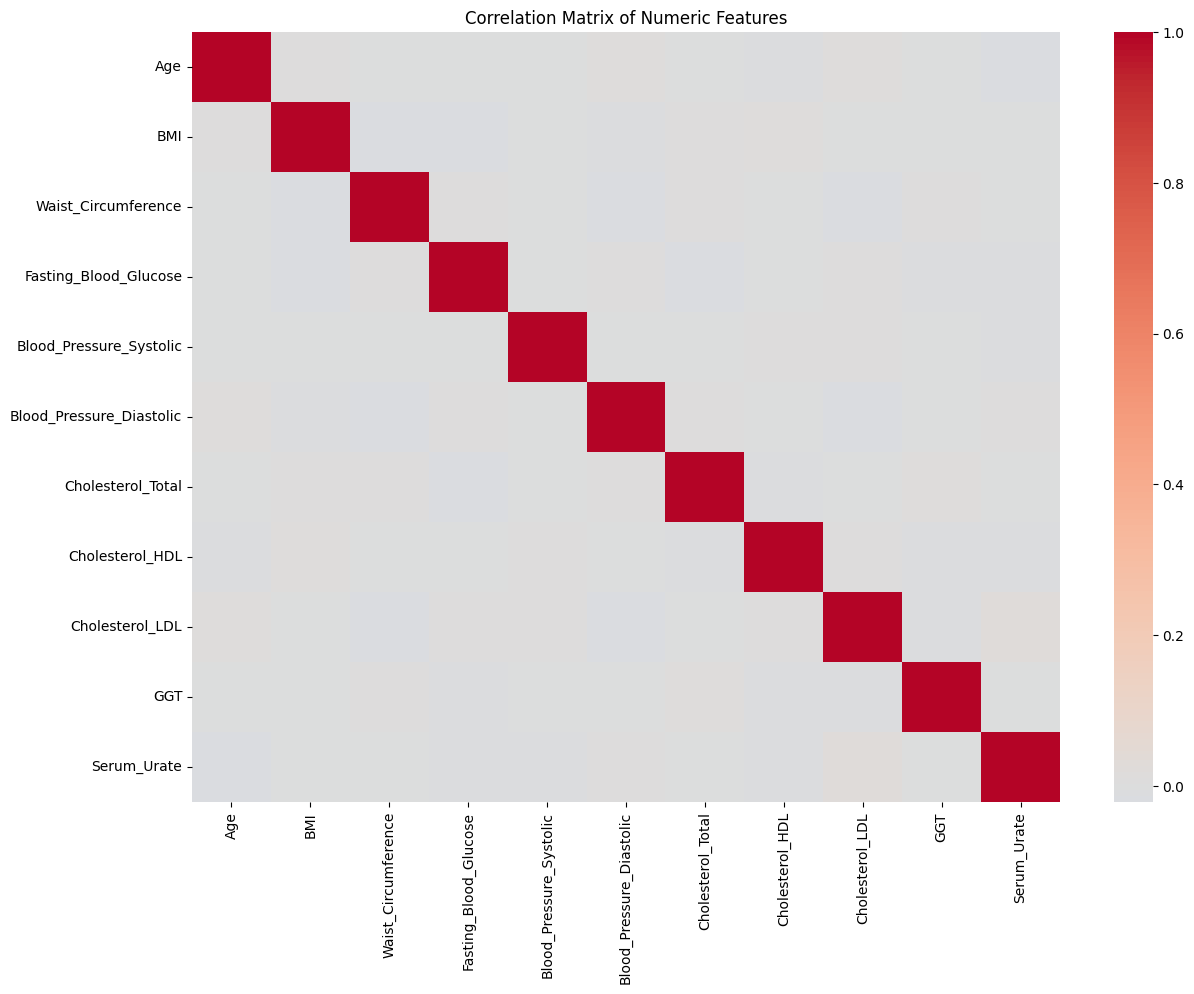

In [16]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numeric Features")
plt.show()


**Interpretation:**

The correlation matrix shows that all numeric features have very weak correlations with each other, with values close to zero. This indicates that each feature contributes unique information to the dataset and there is no concern of multicollinearity. As a result, machine learning models such as logistic regression, random forest, and XGBoost can be trained effectively without needing to remove or combine any highly correlated features.

2. Histogram of Correlation With HbA1c

/tmp/ipython-input-3577341222.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_hba1c.values, y=corr_with_hba1c.index, palette="Blues_r")


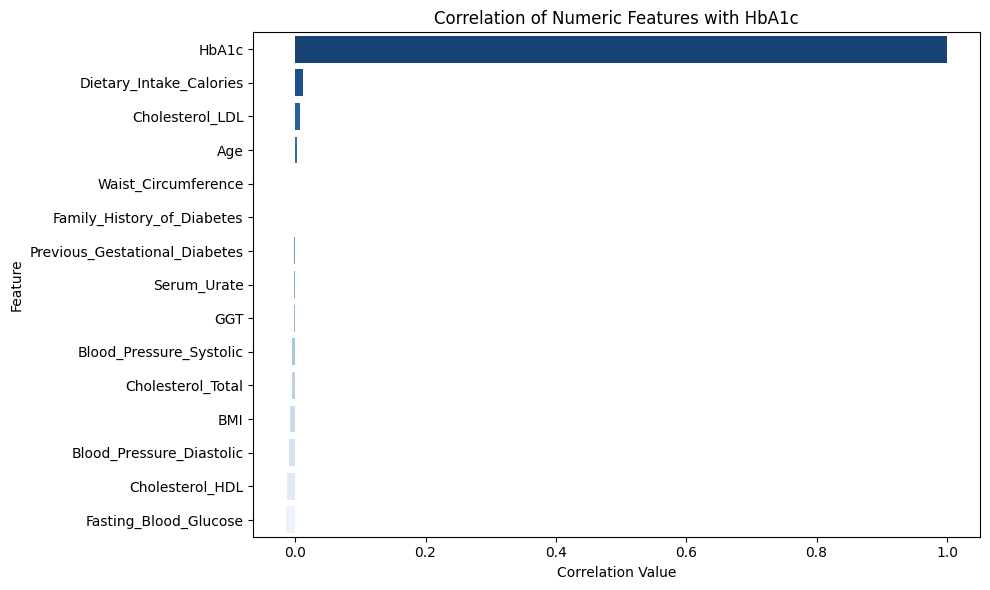

In [17]:
# Compute correlation of each numeric feature with HbA1c
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_with_hba1c = numeric_df.corr()["HbA1c"].sort_values(ascending=False)

# Plot as histogram / bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_hba1c.values, y=corr_with_hba1c.index, palette="Blues_r")

plt.title("Correlation of Numeric Features with HbA1c")
plt.xlabel("Correlation Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**Interpretation:**

All numeric features show very weak correlations with HbA1c, meaning no single variable has strong linear predictive power.

**Defining Target and Features**

In [ ]:
Y = df["HbA1c_Category"]  
X = df.drop(columns=["HbA1c_Category"])  

X.head()

,Age,Sex,Ethnicity,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,GGT,Serum_Urate,Physical_Activity_Level,Dietary_Intake_Calories,Alcohol_Consumption,Smoking_Status,Family_History_of_Diabetes,Previous_Gestational_Diabetes
0,58,Female,White,35.8,83.4,123.9,10.9,152,114,197.8,50.2,99.2,37.5,7.2,Moderate,1538,Moderate,Never,0,1
1,48,Male,Asian,24.1,71.4,183.7,12.8,103,91,261.6,62.0,146.4,88.5,6.1,Moderate,2653,Moderate,Current,0,1
2,34,Female,Black,25.0,113.8,142.0,14.5,179,104,261.0,32.1,164.1,56.2,6.9,Low,1684,Heavy,Former,1,0
3,62,Male,Asian,32.7,100.4,167.4,8.8,176,118,183.4,41.1,84.0,34.4,5.4,Low,3796,Moderate,Never,1,0
4,27,Female,Asian,33.5,110.8,146.4,7.1,122,97,203.2,53.9,92.8,81.9,7.4,Moderate,3161,Heavy,Current,0,0


**Convert categorical columns to dummies**

In [33]:

X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()


,Age,BMI,Waist_Circumference,Fasting_Blood_Glucose,HbA1c,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Total,Cholesterol_HDL,Cholesterol_LDL,...,Previous_Gestational_Diabetes,Sex_Male,Ethnicity_Black,Ethnicity_Hispanic,Ethnicity_White,Physical_Activity_Level_Low,Physical_Activity_Level_Moderate,Alcohol_Consumption_Moderate,Smoking_Status_Former,Smoking_Status_Never
0,58,35.8,83.4,123.9,10.9,152,114,197.8,50.2,99.2,...,1,False,False,False,True,False,True,True,False,True
1,48,24.1,71.4,183.7,12.8,103,91,261.6,62.0,146.4,...,1,True,False,False,False,False,True,True,False,False
2,34,25.0,113.8,142.0,14.5,179,104,261.0,32.1,164.1,...,0,False,True,False,False,True,False,False,True,False
3,62,32.7,100.4,167.4,8.8,176,118,183.4,41.1,84.0,...,0,True,False,False,False,True,False,True,False,True
4,27,33.5,110.8,146.4,7.1,122,97,203.2,53.9,92.8,...,0,False,False,False,False,False,True,False,False,False


**Train/Test Split**

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_encoded, Y,
    test_size=0.3,
    random_state=42,
    stratify=Y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (7000, 24)
Test shape: (3000, 24)


# **Logistic Regression**

1. **Scale Features**

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


2. **Fit Logistic Regression**

In [36]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial"
)

log_reg.fit(X_train_scaled, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

3. **Evaluate Logistic Regression**

Test accuracy (Logistic Regression): 0.9946666666666667

Classification report:
               precision    recall  f1-score   support

    Diabetes       1.00      1.00      1.00      2335
      Normal       0.99      1.00      0.99       472
 Prediabetes       0.99      0.93      0.96       193

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



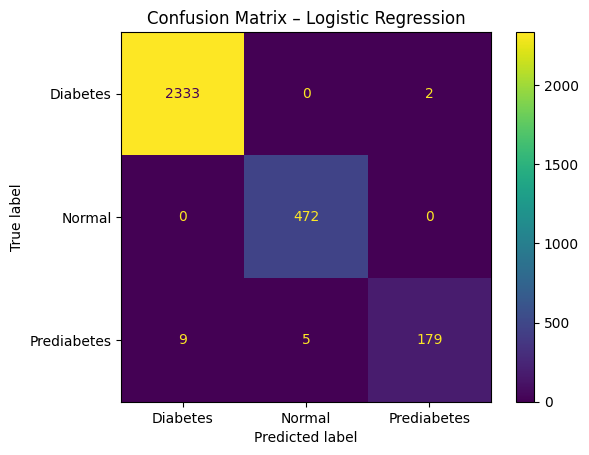

In [55]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Y_pred = log_reg.predict(X_test_scaled)


print("Test accuracy (Logistic Regression):", accuracy_score(Y_test, Y_pred))
print("\nClassification report:\n", classification_report(Y_test, Y_pred))

ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred)
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


**Interpretation:**

1. **Test Accuracy**:

        The logistic regression model predicts the HbA1c category (Normal, Prediabetes, and Diabetes)
        in the test set with a very high accuracy of 99.47%.



2. **Classification Report**:


   A. **Diabetes**
   (Precision = 1.00, Recall = 1.00, F1-Score = 1.00)

        With only two misclassifications and no false positives,
        the model accurately detects nearly all cases of diabetes.



   B. **Normal**
   (Precision = 0.99, Recall = 1.00, F1-Score = 0.99)

        The model perfectly identifies all Normal cases with 0 wrong classifications.



   C. **Prediabetes**
   (Precision = 0.99, Recall = 0.93, F1-Score = 0.96)

       There is slight misclassification with 9 predicted as Diabetes and 5 predicted as Normal.


3. **Confusion Matrix**:



     A. **Diabetes**:
     
          2333 correctly predicted, only 2 misclassified.

          This is nearly perfect.



     B. **Normal**:

          All 472 correctly predicted

          This is again perfect.



     C. **Prediabetes**:

         179 corrected predicted, 9 mistaken as disbetes and 5 mistaken as normal.

         There is slight misclassification.

4. **ROC Curve**

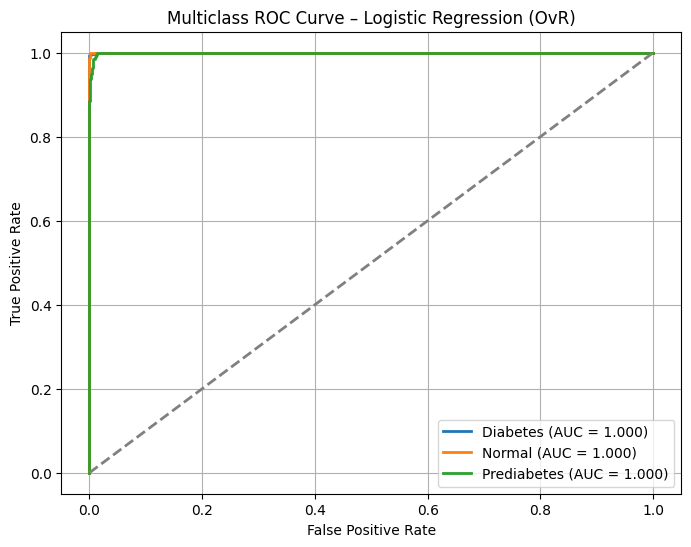

In [41]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. Binarize the labels for OvR ROC
classes = log_reg.classes_
Y_test_bin = label_binarize(Y_test, classes=classes)

# 2. Get predicted probabilities
Y_proba = log_reg.predict_proba(X_test_scaled)

# 3. Plot ROC curves for each class
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], Y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_name} (AUC = {roc_auc:.3f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve – Logistic Regression (OvR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**Interpretation:**

The multiclass ROC curves shows outstanding model performance, with AUC values of 1.0 for all three HbA1c categories. This suggests that the logistic regression model accurately separates cases of normal, prediabetes, and diabetes.

# **Random Forest**



1. **Fit Random Forest**

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, Y_train)


RandomForestClassifier(max_depth=10, n_estimators=300, n_jobs=-1,
                       random_state=42)

2. **Evaluate Random Forest**

Test accuracy (Random Forest): 1.0

Classification report – Random Forest:

              precision    recall  f1-score   support

    Diabetes       1.00      1.00      1.00      2335
      Normal       1.00      1.00      1.00       472
 Prediabetes       1.00      1.00      1.00       193

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



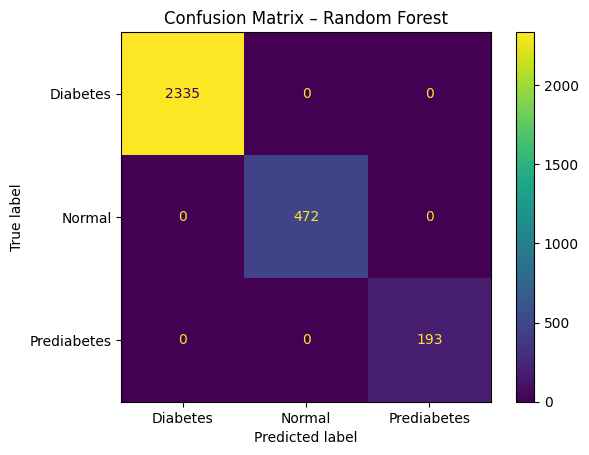

In [47]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Y_pred_rf = rf.predict(X_test)

print("Test accuracy (Random Forest):", accuracy_score(Y_test, Y_pred_rf))
print("\nClassification report – Random Forest:\n")
print(classification_report(Y_test, Y_pred_rf))

ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred_rf)
plt.title("Confusion Matrix – Random Forest")
plt.show()


**Interpretation:**

1. **Test Accuracy and Classification Report**:

       Every single instance was appropriately classified by the model.

         -> Accuracy = 1.00 (100%)

         -> Precision = 1.00

          -> Recall = 1.00

          -> F1-score = 1.00

        Zero misclassifications across all classes.

2. Confusion Matrix:

     A. Diabetes:

        2335 are correctly predicted
        0 misclassified

     B. Normal:

        472 are correctly predicted
        0 misclassified

     C. Prediabetes:

        193 are correctly predicted
        0 misclassified

3. **ROC Curve**

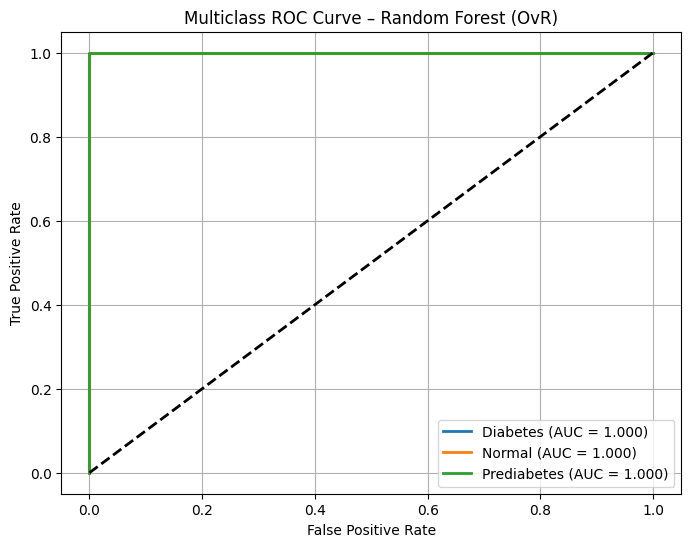

In [48]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

classes = rf.classes_
Y_test_bin = label_binarize(Y_test, classes=classes)

Y_proba_rf = rf.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], Y_proba_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve – Random Forest (OvR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**Interpretation:**

The Random Forest model demonstrates perfect classification performance, with ROC curves for all three HbA1c categories achieving an AUC of 1.0. This suggests that the model is capable of fully separating the classes without producing any incorrect classifications.

4. **Feature Importance**

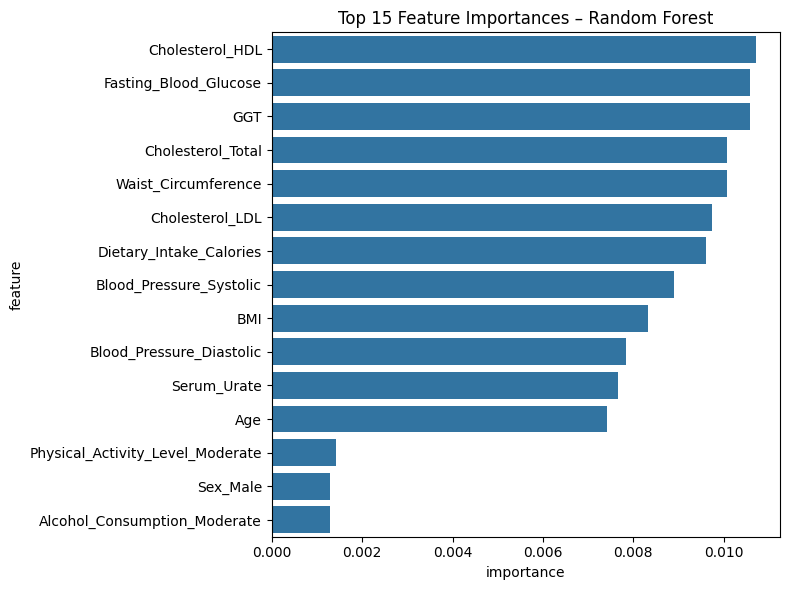

In [51]:
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})

# Drop HbA1c (case-insensitive match to avoid naming issues)
feat_imp = feat_imp[~feat_imp["feature"].str.contains("hba1c", case=False)]

# Sort again
feat_imp = feat_imp.sort_values(by="importance", ascending=False)

# Plot top 15 without HbA1c
plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances – Random Forest")
plt.tight_layout()
plt.show()


**Interpretation:**

Random Forest shows that Cholesterol_HDL, Fasting_Blood_Glucose, GGT, Cholesterol_Total, Waist_Circumference, Cholesterol_LDL are the strong features of sugar levels.

# **Final Reccommendation**

In [64]:
from sklearn.metrics import f1_score, roc_auc_score

# Logistic Regression metrics
log_acc = accuracy_score(Y_test, Y_pred)
log_f1 = f1_score(Y_test, Y_pred, average="macro")
log_auc = roc_auc_score(Y_test_bin, log_reg.predict_proba(X_test_scaled), multi_class="ovr")

# Random Forest metrics
rf_acc = accuracy_score(Y_test, Y_pred_rf)
rf_f1 = f1_score(Y_test, Y_pred_rf, average="macro")
rf_auc = roc_auc_score(Y_test_bin, rf.predict_proba(X_test), multi_class="ovr")

In [65]:
performance_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_acc, rf_acc],
    "F1-Score": [log_f1, rf_f1],
    "ROC-AUC": [log_auc, rf_auc]
})

performance_table


,Model,Accuracy,F1-Score,ROC-AUC
0,Logistic Regression,0.994667,0.9832,0.999832
1,Random Forest,1.000000,1.0000,1.000000


**Interpretation:**

Based on the above table, I reccomend Random Forest as the suitable model as it has achieved perfect accuracy, F1-Score and ROC-AUC Score exceling over Logistics Regression. It gives most accurate and reliable predictions for Diabetes status classification by capturing non linear patterns in the data.